<a href="https://colab.research.google.com/github/amitdey7/MS107/blob/master/Self_Attention_Mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Token Embeddings

In [ ]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
# BPE tokenization

text = "This is an example."

ids = tokenizer.encode(text)
for id in ids:
    print(f"{tokenizer.decode([id]):<10} -> {id:>10}")

This       ->       1212
 is        ->        318
 an        ->        281
 example   ->       1672
.          ->         13


In [ ]:
# Embeddings for input tokens
# Embedding Matrix = [Vocab_size, Embedding_dim]


vocab_size = 10
embedding_dim = 3

token_ids = [1, 3, 4, 6]

In [ ]:
import torch

torch.manual_seed(42)

embedding_matrix = torch.rand(vocab_size, embedding_dim) # vocab_size x emb_dimensions

embeddings = embedding_matrix[token_ids]
print(embeddings)


tensor([[0.9593, 0.3904, 0.6009],
        [0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411],
        [0.2666, 0.6274, 0.2696]])


In [ ]:
token_id = 3
print(embedding_matrix)
print(embedding_matrix.shape)
print(embedding_matrix[token_id])
print(embedding_matrix[token_id].shape)

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408],
        [0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739],
        [0.2666, 0.6274, 0.2696],
        [0.4414, 0.2969, 0.8317],
        [0.1053, 0.2695, 0.3588],
        [0.1994, 0.5472, 0.0062]])
torch.Size([10, 3])
tensor([0.1332, 0.9346, 0.5936])
torch.Size([3])


In [ ]:
# gpt-2 embeddings

vocab_size = tokenizer.n_vocab
print(vocab_size)
embedding_dim = 768

gpt2_embedding_matrix = torch.rand(vocab_size, embedding_dim) # pseudo embedding

tokens_ids = tokenizer.encode("This is an example.")

embeddings = gpt2_embedding_matrix[tokens_ids]
print(embeddings)



50257
tensor([[0.2695, 0.7446, 0.5120,  ..., 0.2068, 0.2683, 0.1163],
        [0.0375, 0.4158, 0.8893,  ..., 0.0884, 0.9570, 0.5608],
        [0.8107, 0.4726, 0.9031,  ..., 0.0483, 0.3741, 0.2708],
        [0.4180, 0.8426, 0.1557,  ..., 0.9406, 0.6207, 0.9662],
        [0.9722, 0.1784, 0.5453,  ..., 0.5127, 0.6993, 0.3651]])


In [ ]:
print(embeddings[0])

tensor([0.2695, 0.7446, 0.5120, 0.7328, 0.8849, 0.4478, 0.6084, 0.4843, 0.6720,
        0.1585, 0.0453, 0.4258, 0.0231, 0.7519, 0.9338, 0.9801, 0.0208, 0.5002,
        0.4748, 0.1483, 0.2714, 0.3697, 0.9775, 0.5547, 0.8617, 0.8971, 0.6583,
        0.3210, 0.6083, 0.7232, 0.2948, 0.4774, 0.4503, 0.7760, 0.9742, 0.0674,
        0.1422, 0.1839, 0.3497, 0.9767, 0.9984, 0.2489, 0.3475, 0.1056, 0.3806,
        0.1598, 0.4598, 0.7309, 0.8400, 0.3126, 0.1728, 0.1473, 0.0277, 0.5715,
        0.8981, 0.9642, 0.1474, 0.8095, 0.3163, 0.6575, 0.8299, 0.2605, 0.0200,
        0.5951, 0.1328, 0.5535, 0.8189, 0.5444, 0.8494, 0.3079, 0.5388, 0.8592,
        0.4973, 0.1377, 0.0898, 0.1627, 0.9662, 0.9958, 0.3762, 0.9508, 0.9157,
        0.1369, 0.7408, 0.5858, 0.6830, 0.5843, 0.3891, 0.9457, 0.2999, 0.3775,
        0.3487, 0.8499, 0.4921, 0.4964, 0.4991, 0.2343, 0.6180, 0.0235, 0.4376,
        0.4724, 0.6048, 0.2482, 0.0132, 0.9798, 0.2078, 0.2573, 0.8115, 0.4492,
        0.1889, 0.1569, 0.0408, 0.5238, 

## Attention Mechanisms

### Simple Weighted Attention

In [ ]:
import torch

text = "Your journey starts with one step"

inputs = torch.tensor(
  [[0.43, 0.15, 0.89],# Your
  [0.55, 0.87, 0.66], # journey
  [0.57, 0.85, 0.64], # starts
  [0.22, 0.58, 0.33], # with
  [0.77, 0.25, 0.10], # one
  [0.05, 0.80, 0.55]] # step
)

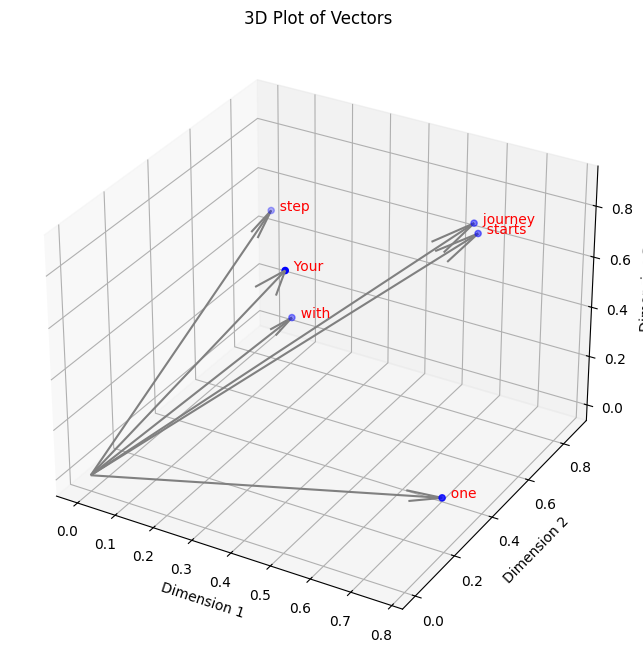

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch

# Define the input vectors and tokens
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your
  [0.55, 0.87, 0.66],  # journey
  [0.57, 0.85, 0.64],  # starts
  [0.22, 0.58, 0.33],  # with
  [0.77, 0.25, 0.10],  # one
  [0.05, 0.80, 0.55]]  # step
)

tokens = ["Your", "journey", "starts", "with", "one", "step"]


vectors = inputs.numpy()

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract x, y, z coordinates
x = vectors[:, 0]
y = vectors[:, 1]
z = vectors[:, 2]


ax.scatter(x, y, z, c='blue', marker='o')


for i, token in enumerate(tokens):
    ax.text(x[i], y[i], z[i], f'  {token}', color='red', fontsize=10)
    ax.quiver(0, 0, 0, x[i], y[i], z[i], color='gray', arrow_length_ratio=0.1)

# Set labels for the axes
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')

ax.set_title('3D Plot of Vectors')


plt.show()

#### Calculating attention for a single token

In [ ]:
print(inputs[0])
inputs.shape

tensor([0.4300, 0.1500, 0.8900])


torch.Size([6, 3])

In [ ]:
query = inputs[1]
query

tensor([0.5500, 0.8700, 0.6600])

In [ ]:


attn_scores_2 = torch.empty(inputs.shape[0])
print(attn_scores_2.shape)
for idx, ele in enumerate(inputs[0]):
  attn_scores_2[1] += inputs[1][idx] * query[idx]

attn_scores_2[1]

torch.Size([6])


tensor(1.4950)

In [ ]:
# taking dot product

for idx, x_i in enumerate(inputs):
  attn_scores_2[idx] = torch.dot(x_i, query)

attn_scores_2

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

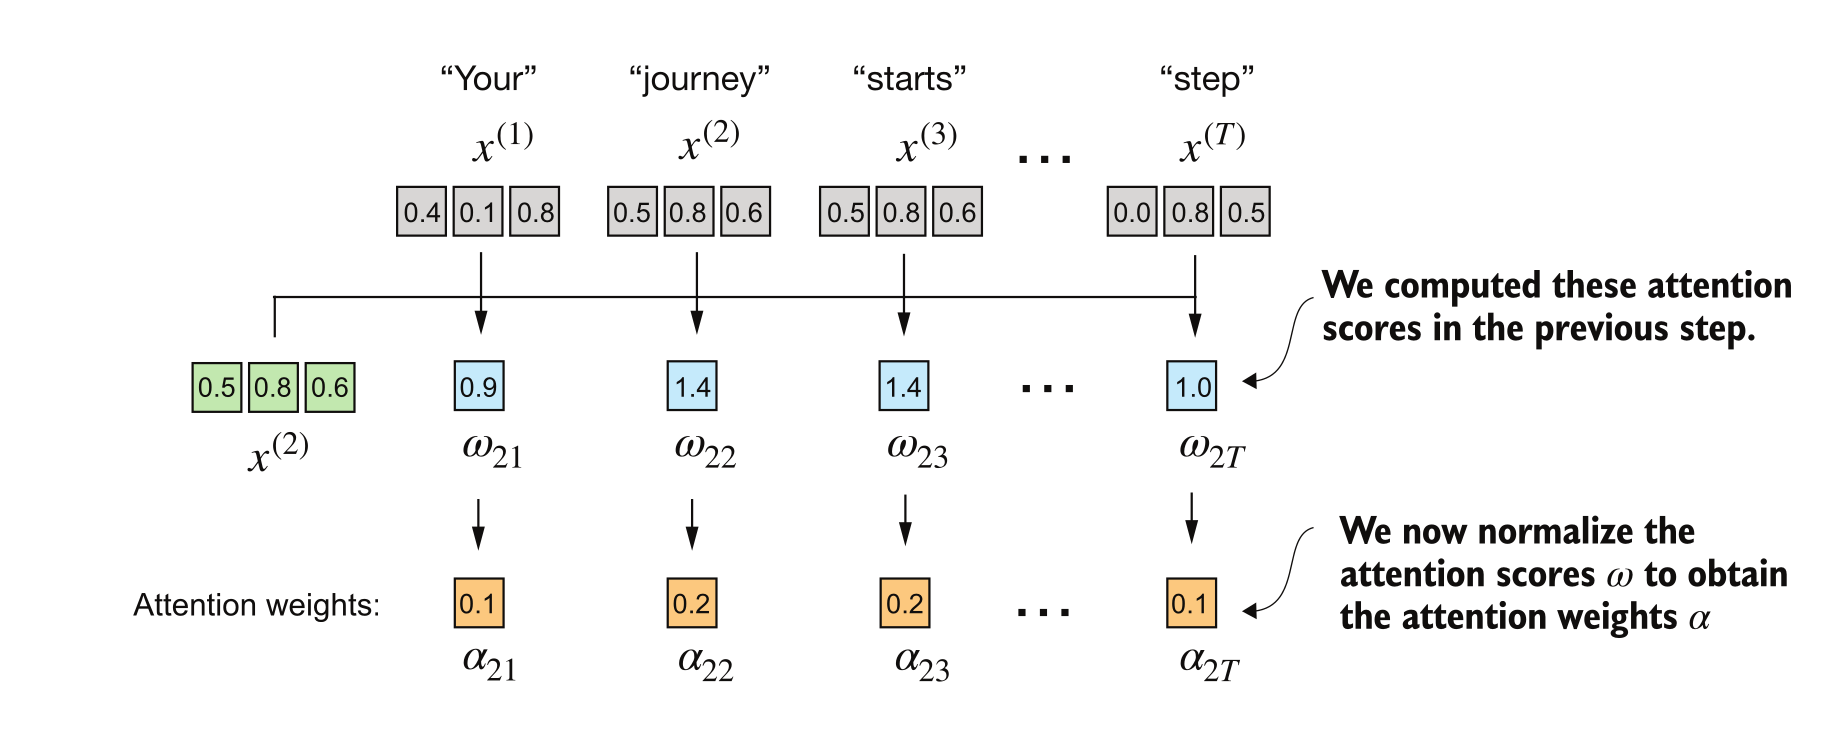

In [ ]:
attn_weights_2_normalized = attn_scores_2 / torch.sum(attn_scores_2)
print("Attn Weights normalized : ", attn_weights_2_normalized)
print("Attn weights sum", torch.sum(attn_weights_2_normalized))

Attn Weights normalized :  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Attn weights sum tensor(1.0000)


In [ ]:
def softmax_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)
print(attn_weights_2_naive.sum(dim=0) )

tensor(1.)


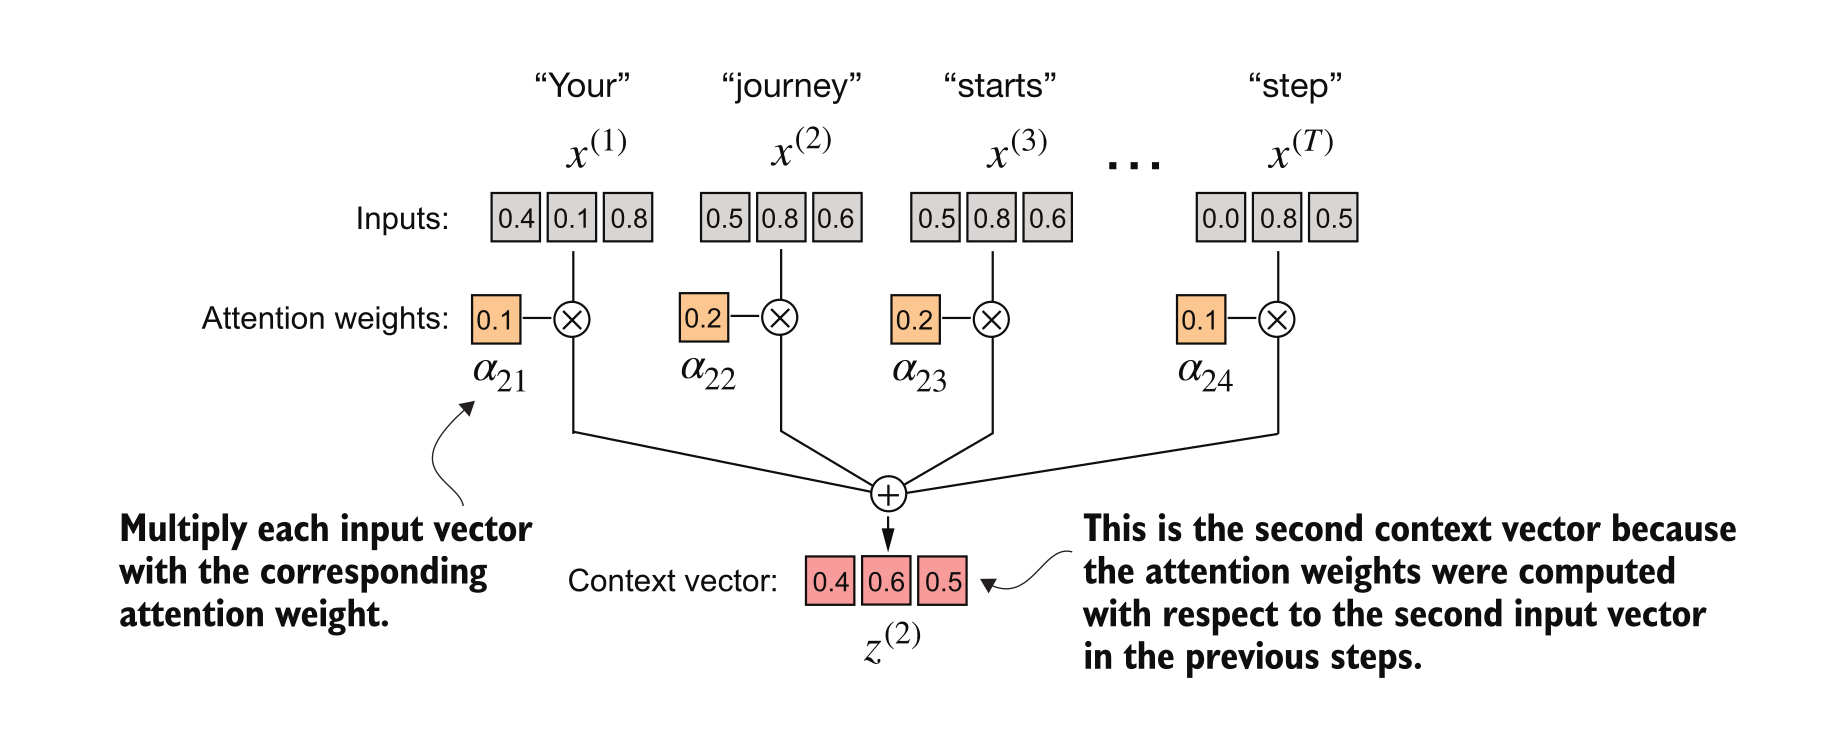

In [ ]:
### Calculating context vectors

context_2_naive = torch.zeros(query.shape)
context_2_naive

for idx, ele in enumerate(inputs):
  context_vec_2 = attn_weights_2_naive[idx] * ele
  context_2_naive += context_vec_2

print(context_2_naive)

tensor([0.4419, 0.6515, 0.5683])


### Calculating attention scores for all queries

In [ ]:


import torch

attn_scores = torch.zeros((len(inputs), len(inputs)))

for i, ele in enumerate(inputs):
  for j, ele2 in enumerate(inputs):
    attn_scores[i, j] = torch.dot(ele, ele2)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [ ]:
attn_scores_normalized = torch.zeros((len(inputs), len(inputs)))

for i, ele in enumerate(attn_scores):
  attn_scores_normalized[i] = ele / torch.sum(ele)

print(attn_scores_normalized)

tensor([[0.2241, 0.2140, 0.2113, 0.1066, 0.1026, 0.1415],
        [0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656],
        [0.1454, 0.2277, 0.2248, 0.1280, 0.1104, 0.1637],
        [0.1304, 0.2313, 0.2275, 0.1354, 0.0953, 0.1801],
        [0.1436, 0.2219, 0.2245, 0.1090, 0.2088, 0.0921],
        [0.1350, 0.2325, 0.2269, 0.1405, 0.0628, 0.2022]])


In [ ]:
attn_scores_normalized = torch.softmax(attn_scores, dim=-1)

print(attn_scores_normalized)
print(torch.sum(attn_scores_normalized, dim=-1))

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [ ]:
all_context_vectors = attn_scores_normalized @ inputs
print(all_context_vectors)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


## Self attention with trainable weights




In [ ]:
inputs.shape

torch.Size([6, 3])

In [ ]:
# Define the input vectors and tokens
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your
  [0.55, 0.87, 0.66],  # journey
  [0.57, 0.85, 0.64],  # starts
  [0.22, 0.58, 0.33],  # with
  [0.77, 0.25, 0.10],  # one
  [0.05, 0.80, 0.55]]  # step
)

inputs.shape

torch.Size([6, 3])

In [ ]:
d_in = inputs.shape[1]
d_out = 2

W_q = torch.nn.Parameter(torch.rand(d_in, d_out))
W_k = torch.nn.Parameter(torch.rand(d_in, d_out))
W_v = torch.nn.Parameter(torch.rand(d_in, d_out))
W_v


Parameter containing:
tensor([[3.4790e-01, 8.8280e-04],
        [8.0293e-02, 8.5483e-02],
        [1.2759e-01, 9.9764e-01]], requires_grad=True)

In [ ]:
x_2 = inputs[1]
print(x_2)

q_2 = torch.matmul(x_2, W_q)
k_2 = torch.matmul(x_2, W_k)
v_2 = torch.matmul(x_2, W_v)

print(q_2)

tensor([0.5500, 0.8700, 0.6600])
tensor([0.8723, 0.9651], grad_fn=<SqueezeBackward4>)


In [ ]:
# for all tokens
queries = torch.matmul(inputs, W_q)
keys = torch.matmul(inputs, W_k)
values = torch.matmul(inputs, W_v)



In [ ]:
attn_score_2 = torch.matmul(q_2, keys.T)
print(attn_score_2)

tensor([1.6476, 2.1349, 2.1215, 1.1175, 1.2825, 1.3281],
       grad_fn=<SqueezeBackward4>)


In [ ]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_score_2 / d_k ** 0.5,  dim=-1)
print(attn_weights_2)

tensor([0.1648, 0.2326, 0.2304, 0.1133, 0.1273, 0.1315],
       grad_fn=<SoftmaxBackward0>)


In [ ]:
attn_weights_2.sum()

tensor(1.0000, grad_fn=<SumBackward0>)

In [ ]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.2829, 0.6227], grad_fn=<SqueezeBackward4>)


In [ ]:
## SelfAttentionClass

class SelfAttention(torch.nn.Module):
  def __init__(self, d_in , d_out):
    super(SelfAttention, self).__init__()

    self.W_q = torch.nn.Parameter(torch.rand(d_in, d_out))
    self.W_k = torch.nn.Parameter(torch.rand(d_in, d_out))
    self.W_v = torch.nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    q = torch.matmul(x, self.W_q)
    k = torch.matmul(x, self.W_k)
    v = torch.matmul(x, self.W_v)

    attn_scores = torch.matmul(q, k.T)

    d_k = k.shape[1]
    attn_weights = torch.softmax(attn_scores / d_k ** 0.5, dim=-1)

    context = torch.matmul(attn_weights, v)

    return context

In [ ]:
torch.manual_seed(42)
sa_v1 = SelfAttention(d_in=3, d_out=2)
sa_v1(inputs)

tensor([[1.3751, 0.8610],
        [1.4201, 0.8892],
        [1.4198, 0.8890],
        [1.3533, 0.8476],
        [1.3746, 0.8606],
        [1.3620, 0.8532]], grad_fn=<MmBackward0>)

## Improved Self Attention

In [ ]:
class SelfAttention(torch.nn.Module):
  def __init__(self, d_in , d_out, qkv_bias = False):
    super(SelfAttention, self).__init__()
    self.W_query = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = torch.nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    attn_scores = torch.matmul(queries, keys.T)
    d_k = keys.shape[1]
    attn_weights = torch.softmax(attn_scores / d_k ** 0.5, dim=-1)

    context = torch.matmul(attn_weights, values)

    return context

In [ ]:

sa = SelfAttention(d_in=3, d_out=2)
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [ ]:
keys = sa.W_key(inputs)
queries = sa.W_query(inputs)
values = sa.W_value(inputs)

attn_scores = torch.matmul(queries, keys.T)
d_k = keys.shape[1]
attn_weights = torch.softmax(attn_scores / d_k ** 0.5, dim=-1)

print(attn_weights)

context = torch.matmul(attn_weights, values)

print(context)



tensor([[0.1572, 0.1693, 0.1694, 0.1676, 0.1700, 0.1665],
        [0.1650, 0.1700, 0.1701, 0.1639, 0.1667, 0.1642],
        [0.1651, 0.1702, 0.1702, 0.1638, 0.1666, 0.1641],
        [0.1669, 0.1681, 0.1681, 0.1652, 0.1663, 0.1655],
        [0.1673, 0.1711, 0.1711, 0.1621, 0.1656, 0.1629],
        [0.1659, 0.1672, 0.1672, 0.1665, 0.1669, 0.1664]],
       grad_fn=<SoftmaxBackward0>)
tensor([[0.1712, 0.1184],
        [0.1750, 0.1207],
        [0.1751, 0.1208],
        [0.1751, 0.1209],
        [0.1764, 0.1215],
        [0.1743, 0.1205]], grad_fn=<MmBackward0>)


## Causal Attention


In [ ]:
sa = SelfAttention(d_in=3, d_out=2)

queries = sa.W_query(inputs)
keys = sa.W_key(inputs)
values = sa.W_value(inputs)

attn_scores = torch.matmul(queries, keys.T)
attn_scores


tensor([[0.0724, 0.0896, 0.0903, 0.0428, 0.0772, 0.0398],
        [0.2357, 0.3837, 0.3787, 0.2181, 0.1805, 0.2809],
        [0.2314, 0.3759, 0.3710, 0.2134, 0.1778, 0.2744],
        [0.1489, 0.2493, 0.2455, 0.1436, 0.1089, 0.1887],
        [0.0881, 0.1286, 0.1278, 0.0688, 0.0789, 0.0805],
        [0.1984, 0.3372, 0.3318, 0.1957, 0.1412, 0.2597]],
       grad_fn=<MmBackward0>)

In [ ]:
# create a mask
context_length = attn_scores.shape[-1]
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
mask

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])

In [ ]:
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
masked

tensor([[0.0724,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.2357, 0.3837,   -inf,   -inf,   -inf,   -inf],
        [0.2314, 0.3759, 0.3710,   -inf,   -inf,   -inf],
        [0.1489, 0.2493, 0.2455, 0.1436,   -inf,   -inf],
        [0.0881, 0.1286, 0.1278, 0.0688, 0.0789,   -inf],
        [0.1984, 0.3372, 0.3318, 0.1957, 0.1412, 0.2597]],
       grad_fn=<MaskedFillBackward0>)

In [ ]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
attn_weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4739, 0.5261, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3114, 0.3449, 0.3437, 0.0000, 0.0000, 0.0000],
        [0.2415, 0.2593, 0.2586, 0.2406, 0.0000, 0.0000],
        [0.1985, 0.2043, 0.2042, 0.1958, 0.1972, 0.0000],
        [0.1612, 0.1778, 0.1771, 0.1609, 0.1548, 0.1683]],
       grad_fn=<SoftmaxBackward0>)

### Attention + Dropout

In [ ]:
# dropout example
import torch.nn as nn

layer = torch.rand(1,10)
droput = nn.Dropout(p=0.5)
layer

tensor([[0.6440, 0.7071, 0.6581, 0.4913, 0.8913, 0.1447, 0.5315, 0.1587, 0.6542,
         0.3278]])

In [ ]:
# training time
droput.train()

print(layer)
print(droput(layer))

tensor([[0.6440, 0.7071, 0.6581, 0.4913, 0.8913, 0.1447, 0.5315, 0.1587, 0.6542,
         0.3278]])
tensor([[1.2880, 1.4142, 0.0000, 0.0000, 0.0000, 0.2895, 1.0630, 0.3175, 0.0000,
         0.6556]])


In [ ]:
# inference time
droput.eval()

print(layer)
print(droput(layer))

tensor([[0.6440, 0.7071, 0.6581, 0.4913, 0.8913, 0.1447, 0.5315, 0.1587, 0.6542,
         0.3278]])
tensor([[0.6440, 0.7071, 0.6581, 0.4913, 0.8913, 0.1447, 0.5315, 0.1587, 0.6542,
         0.3278]])


In [ ]:
# Dropout in attention
dropout = nn.Dropout(0.8)
print(attn_weights)
attn_weights_dropout = dropout(attn_weights)
attn_weights_dropout

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4739, 0.5261, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3114, 0.3449, 0.3437, 0.0000, 0.0000, 0.0000],
        [0.2415, 0.2593, 0.2586, 0.2406, 0.0000, 0.0000],
        [0.1985, 0.2043, 0.2042, 0.1958, 0.1972, 0.0000],
        [0.1612, 0.1778, 0.1771, 0.1609, 0.1548, 0.1683]],
       grad_fn=<SoftmaxBackward0>)


tensor([[5.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.7185, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.2930, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.8043, 0.7739, 0.8415]],
       grad_fn=<MulBackward0>)

In [ ]:
# Final Causal Attention class
# Learned weights, Masking and Dropout
# Support for batch of inputs


class CausalAttention(nn.Module):

    def __init__(self, d_model, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_model, d_out, bias=qkv_bias) # 512 x 128
        self.W_key   = nn.Linear(d_model, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_model, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_model = x.shape  # B x L x model_dimension (2 x 10 x 512)
        keys = self.W_key(x)              # B x L x d_out (2 x 10 x 512 . 512 x 128) => (2 x 10 x 128)
        queries = self.W_query(x)         # B x L x d_out
        values = self.W_value(x)          # B x L x d_out

        attn_scores = queries @ keys.transpose(1, 2) # (B x L x d_out) @ (B x d_out x L) => B x L x L
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is greater than the supported context_size
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1) # B x L x L
        attn_weights = self.dropout(attn_weights) # B x L x L
        context_vec = attn_weights @ values # (B x L x L) x (B x L x d_out ) => (B x L x d_out)
        return context_vec



In [ ]:
inputs_batched = torch.stack([inputs, inputs, inputs])
inputs_batched

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

In [ ]:
causal_attn = CausalAttention(d_model=3, d_out=2, context_length=6, dropout=0.2)
causal_attn(inputs_batched)

tensor([[[-0.3158, -0.1185],
         [-0.1752, -0.0657],
         [-0.3030,  0.1281],
         [-0.4005,  0.1072],
         [-0.3220,  0.1001],
         [-0.2746,  0.0807]],

        [[-0.3158, -0.1185],
         [-0.1752, -0.0657],
         [-0.3030,  0.1281],
         [-0.4005,  0.1072],
         [-0.3220,  0.1001],
         [-0.3554,  0.1146]],

        [[-0.3158, -0.1185],
         [-0.1752, -0.0657],
         [-0.1543,  0.0648],
         [-0.4005,  0.1072],
         [-0.3220,  0.1001],
         [-0.3554,  0.1146]]], grad_fn=<UnsafeViewBackward0>)

In [ ]:
inputs_single_batch = inputs.unsqueeze(0)
causal_attn(inputs_single_batch)

tensor([[[-0.3158, -0.1185],
         [-0.3978,  0.0278],
         [-0.3030,  0.1281],
         [-0.2842,  0.0577],
         [-0.1656,  0.0276],
         [-0.3047,  0.0882]]], grad_fn=<UnsafeViewBackward0>)

## Multi Head Attention

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList([CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
        for _ in range(num_heads)
        ]
    )
  def forward(self, x):
    return torch.cat([head(x) for head in self.heads], dim=-1)

In [ ]:
mha = MultiHeadAttentionWrapper(d_in=3, d_out=1, context_length=6, dropout=0.2, num_heads=2)
mha(inputs.unsqueeze(0))

tensor([[[ 0.9670,  0.0000],
         [ 0.6835, -0.2468],
         [ 1.2183, -0.2581],
         [ 1.0979, -0.1684],
         [ 0.8272, -0.2736],
         [ 1.0093, -0.2641]]], grad_fn=<CatBackward0>)

### Small Matrices vs One Big Matrix

```
LOOP-BASED                        BLOCK-BASED
---------                        -----------

12 × (512 × 64) GEMMs            1 × (512 × 768) GEMM
many kernel launches             one kernel launch
low arithmetic intensity         high arithmetic intensity
hardware underutilized           hardware saturated

Same FLOPs. Very different speed.

```



In [ ]:
import time

assert torch.cuda.is_available(), "Enable GPU in Colab (Runtime → Change runtime type)"
device = "cuda"

torch.manual_seed(0)


B = 128        # number of independent matrices
M = 64
K = 64
N = 64

A = torch.randn(B, M, K, device=device)
Bmat = torch.randn(B, K, N, device=device)


def benchmark(fn, iters=50, warmup=10):
  # warmup
  for _ in range(warmup):
      fn()
  torch.cuda.synchronize()

  start = time.time()
  for _ in range(iters):
      fn()
  torch.cuda.synchronize()
  end = time.time()

  return (end - start) / iters


def loop_matmul():
    outs = []
    for i in range(B):
        outs.append(A[i] @ Bmat[i])
    return outs


t_loop = benchmark(loop_matmul)
print(f"Loop-based attention: {t_loop*1000:.2f} ms")

def batched_matmul():
    return torch.bmm(A, Bmat)

t_block = benchmark(batched_matmul)
print(f"Block-based attention: {t_block*1000:.2f} ms")

# compare both matrces
loop_res = loop_matmul()
loop_res = torch.stack(loop_res)
batched_res = batched_matmul()

print("results mathc?", torch.allclose(loop_res, batched_res, atol=1e-5))

print(f"Speed up observed : {t_loop / t_block:.2f}x")

AssertionError: Enable GPU in Colab (Runtime → Change runtime type)

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.d_out = d_out # context vector
    self.d_in = d_in # token embedding size
    self.num_heads = num_heads
    self.context_length = context_length
    self.dropout = dropout

    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    self.out_proj = nn.Linear(d_out, d_out)

  def forward(self, X):
    batches, num_tokens, d_in = X.shape # B x L x d_in

    queries = self.W_query(X) # (B x L X d_in) => B x L x d_out)
    keys = self.W_key(X) # (B x L X d_in)  => B x L x d_out)
    values = self.W_value(X) # (B x L X d_in) => B x L x d_out)

    queries = queries.reshape(batches, num_tokens, self.num_heads, self.head_dim) # B x L x num_heads x head_dim
    keys = keys.reshape(batches, num_tokens, self.num_heads, self.head_dim) # B x L x num_heads x head_dim
    values = values.reshape(batches, num_tokens, self.num_heads, self.head_dim) # B x L x num_heads x head_dim

    queries = queries.transpose(1, 2) # B x num_heads x L x head_dim
    keys = keys.transpose(1, 2) # B x num_heads x L x head_dim
    values = values.transpose(1, 2) # B x num_heads x L x head_dim

    attn_scores = queries @ keys.transpose(2, 3) # (B x num_heads x L x head_dim) @ (B x num_heads x head_dim x L) => B x num_heads x L x L

    attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf) # B x num_heads x L x L

    attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1) # L x L => (1 x 1 x L x L)
    attn_weights = nn.Dropout(self.dropout)(attn_weights) # B x num_heads x L x L

    context_vec = attn_weights @ values # (B x num_heads x L x L) @ (B x num_heads x L x head_dim) => (B x num_heads x L x head_dim)

    context_vec = context_vec.transpose(1, 2) # B x L x num_heads x head_dim
    context_vec = context_vec.reshape(batches, num_tokens, self.d_out) # B x L x d_out

    return self.out_proj(context_vec) # (B x L x d_out) @ (d_out x d_out) => B x L x d_out




### GPT-2's MHA

In [ ]:
GPT_2_SMALL = {
    "d_model": 768, # d_in
    "num_heads": 12,
    "context_length": 1024,
    "dropout": 0.1
}


gpt2_sa = MultiHeadAttention(d_in = GPT_2_SMALL['d_model'],
                             d_out=GPT_2_SMALL["d_model"],
                             context_length=GPT_2_SMALL["context_length"],
                             dropout=GPT_2_SMALL["dropout"],
                             num_heads=GPT_2_SMALL["num_heads"]
                             )

inputs = torch.rand(2, 1024, 768)
gpt2_sa(inputs).shape

# in_dimensions -> MHA -> out_dims
# in_dims == out_dims

In [ ]:
total_sum = 0
for name, param in gpt2_sa.named_parameters():
  total_sum += param.numel()
  print(f"Name: {name:<30} || Shape : {str(param.shape):<30} Number of paramters : {param.numel()}")



print(f"Total number of parameters in MHA layer :  {total_sum}")